In [82]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
foldername = 'results/20250228/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [72]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",34271,"[525, 489, 213, 206]",1.005113,"[[588.5277777777778, 656.3611111111111]]",0.984400,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",853,34271.0,...,104.445192,"(588.5277777777778, 656.3611111111111)",218.277347,204.057510,121.143927,115.934163,226.503837,A4-2h-01,A4-2h,1.11
0,"[[False, False, False, False, False, False, Fa...",35006,"[532, 514, 212, 212]",0.993316,"[[543.9166666666666, 584.9166666666666]]",0.983653,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",857,35006.0,...,105.559253,"(543.9166666666666, 584.9166666666666)",219.020547,207.884079,121.556404,117.170771,230.751328,A4-2h-02,A4-2h,1.11
1,"[[False, False, False, False, False, False, Fa...",34344,"[451, 180, 218, 214]",1.001823,"[[558.3333333333333, 196.7777777777778]]",0.983394,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",873,34346.0,...,104.556371,"(558.3333333333333, 196.7777777777778)",221.542321,204.182831,122.955988,116.057572,226.642942,A4-2h-02,A4-2h,1.11
2,"[[False, False, False, False, False, False, Fa...",34529,"[244, 139, 214, 215]",0.999405,"[[334.99999999999994, 304.1111111111111]]",0.983097,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",863,34528.0,...,104.837599,"(334.99999999999994, 304.1111111111111)",216.748702,205.752945,120.295530,116.369734,228.385769,A4-2h-02,A4-2h,1.11
3,"[[False, False, False, False, False, False, Fa...",34426,"[309, 340, 211, 208]",1.012048,"[[334.99999999999994, 370.5833333333333]]",0.975442,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",881,34425.0,...,104.681116,"(334.99999999999994, 370.5833333333333)",229.839074,206.848206,127.560686,116.196039,229.601508,A4-2h-02,A4-2h,1.11


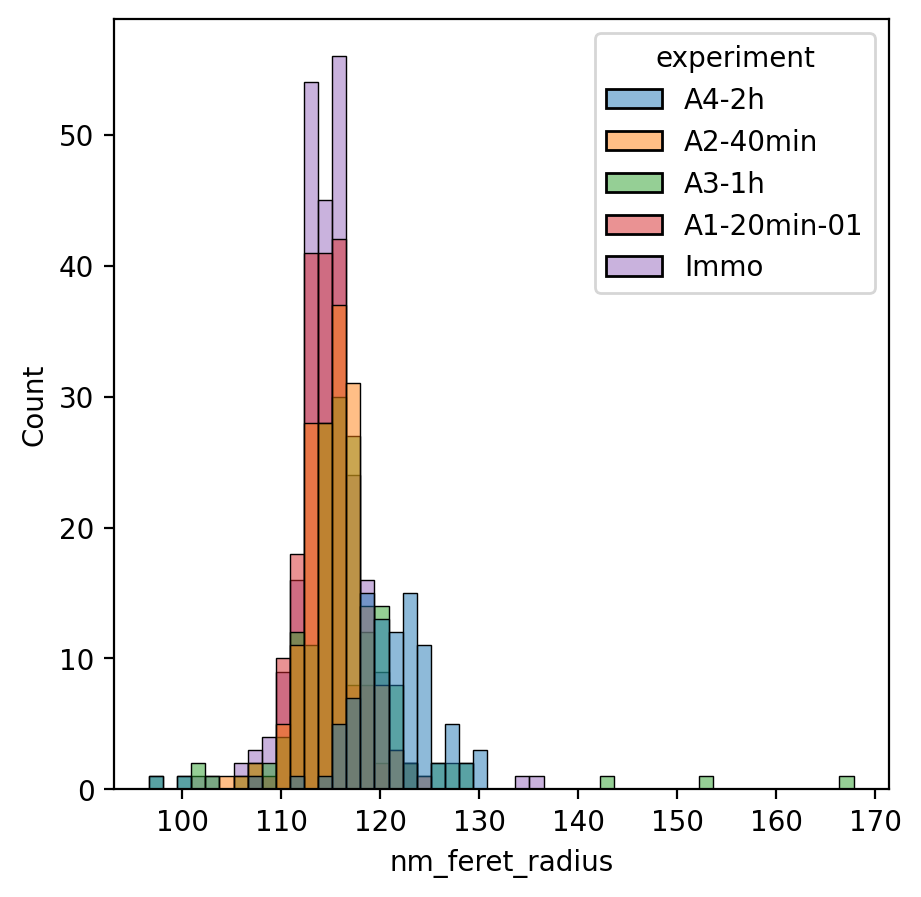

In [73]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [74]:
exclusion_list = []

In [80]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

In [96]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 2, 90, 130, x['nm_per_pixel'], True), axis=1)

/var/folders/hx/cphylf_x45bdc9bx9rm660lh0000gn/T/ipykernel_47349/1907375500.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 2, 90, 130, x['nm_per_pixel'], True), axis=1)


In [97]:
df_filtered

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel,hough_radius
0,"[[False, False, False, False, False, False, Fa...",34271,"[525, 489, 213, 206]",1.005113,"[[588.5277777777778, 656.3611111111111]]",0.984400,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",853,34271.0,...,"(588.5277777777778, 656.3611111111111)",218.277347,204.057510,121.143927,115.934163,226.503837,A4-2h-01,A4-2h,1.11,116.994002
1,"[[False, False, False, False, False, False, Fa...",34344,"[451, 180, 218, 214]",1.001823,"[[558.3333333333333, 196.7777777777778]]",0.983394,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",873,34346.0,...,"(558.3333333333333, 196.7777777777778)",221.542321,204.182831,122.955988,116.057572,226.642942,A4-2h-02,A4-2h,1.11,115.884002
2,"[[False, False, False, False, False, False, Fa...",34529,"[244, 139, 214, 215]",0.999405,"[[334.99999999999994, 304.1111111111111]]",0.983097,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",863,34528.0,...,"(334.99999999999994, 304.1111111111111)",216.748702,205.752945,120.295530,116.369734,228.385769,A4-2h-02,A4-2h,1.11,108.780000
3,"[[False, False, False, False, False, False, Fa...",34426,"[309, 340, 211, 208]",1.012048,"[[334.99999999999994, 370.5833333333333]]",0.975442,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",881,34425.0,...,"(334.99999999999994, 370.5833333333333)",229.839074,206.848206,127.560686,116.196039,229.601508,A4-2h-02,A4-2h,1.11,115.884002
1,"[[False, False, False, False, False, False, Fa...",32328,"[461, 449, 202, 205]",1.007344,"[[513.6666666666666, 584.9166666666666]]",0.984415,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",821,32328.0,...,"(513.6666666666666, 584.9166666666666)",211.851363,195.543167,117.577506,112.599759,217.052915,A4-2h-03,A4-2h,1.11,117.660000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,"[[False, False, False, False, False, False, Fa...",32040,"[761, 685, 202, 200]",1.022048,"[[900.8055555555555, 692.0833333333334]]",0.991545,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",809,32040.0,...,"(900.8055555555555, 692.0833333333334)",206.409787,200.000000,114.557432,112.097079,222.000000,Immo-13,Immo,1.11,112.775998
13,"[[False, False, False, False, False, False, Fa...",31449,"[928, 99, 201, 202]",1.022331,"[[1079.25, 268.3333333333333]]",0.993471,"[477, 0, 803, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",811,31449.0,...,"(1079.25, 268.3333333333333)",205.645326,193.986664,114.133156,111.058413,215.325197,Immo-13,Immo,1.11,111.888003
14,"[[False, False, False, False, False, False, Fa...",31045,"[224, 120, 196, 197]",1.016300,"[[379.66666666666663, 161.0]]",0.992238,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",791,31045.0,...,"(379.66666666666663, 161.0)",203.403540,193.803238,112.888965,110.342768,215.121594,Immo-13,Immo,1.11,109.890000
16,"[[False, False, False, False, False, False, Fa...",30336,"[510, 0, 208, 176]",1.013832,"[[588.5277777777778, 161.0]]",0.988796,"[477, 0, 803, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",642,30343.0,...,"(588.5277777777778, 161.0)",211.248669,176.000000,117.243011,109.075497,195.360000,Immo-13,Immo,1.11,113.664002


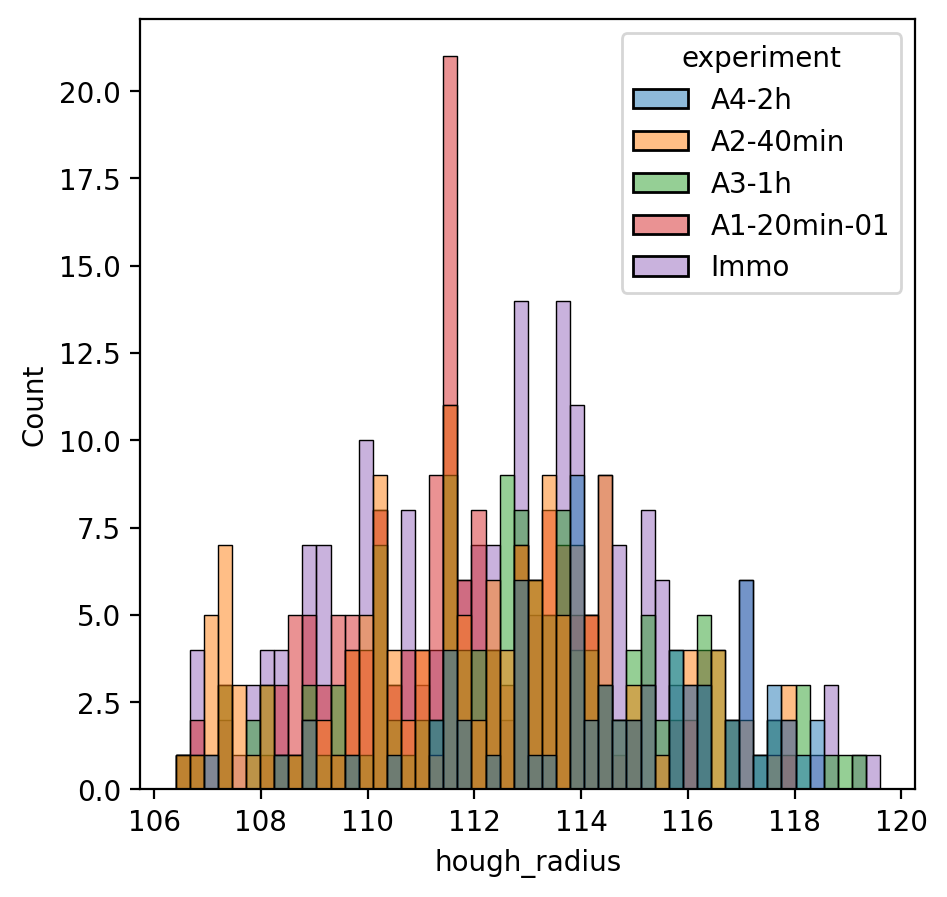

In [98]:
plt.figure(figsize=(5,5), dpi=200)

sns.histplot(data=df_filtered.dropna(), x='hough_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [99]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
q5, q95 = df_filtered[filter_quantity].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered[filter_quantity] < q95) & (df_filtered[filter_quantity] > q5)]

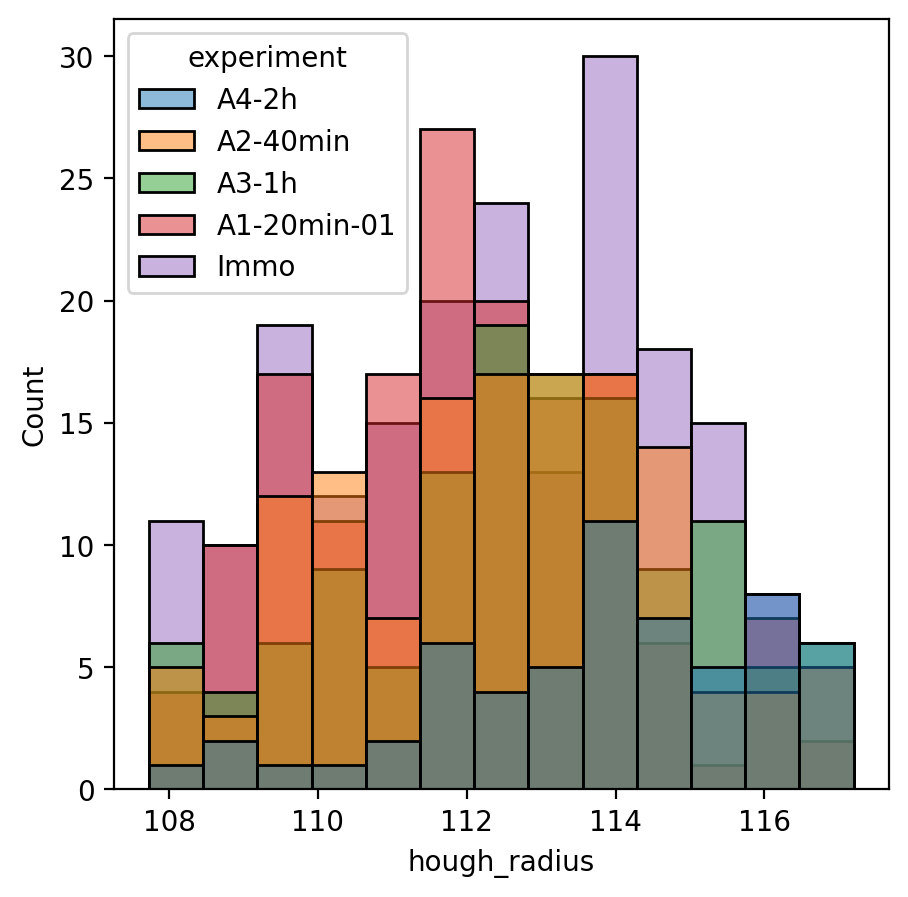

In [100]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x=filter_quantity, hue='experiment')
plt.savefig(f'{foldername}/filtered_particle_measurements')

<Figure size 1000x1000 with 0 Axes>

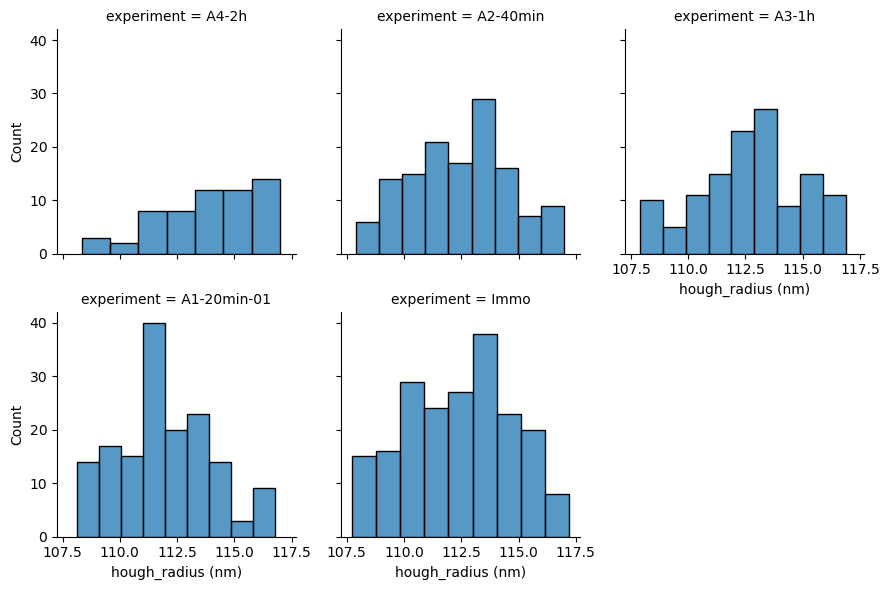

In [101]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [121]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=filter_quantity)
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
0,113.220000,113.441997,113.664002,116.994002,114.774002
1,109.668003,109.668003,116.550000,115.884002,113.885998
2,114.995998,112.998003,113.220000,108.780000,108.114002
3,112.110000,109.890000,115.661997,115.884002,113.885998
4,114.108003,110.334002,113.885998,111.888003,108.780000


In [122]:
experiment_df.describe()

experiment,A1-20min-01,A2-40min,A3-1h,A4-2h,Immo
count,155.000000,134.000000,126.000000,59.000000,200.000000
mean,111.905187,112.461224,112.749857,113.874712,112.385580
std,2.031442,2.124872,2.258480,2.193208,2.340626
min,108.114002,107.891997,107.881997,108.335998,107.730000
25%,110.333997,110.778003,111.444002,112.775998,110.555998
50%,111.665998,112.554002,112.891997,113.885998,112.665000
75%,113.441997,113.885998,114.228003,115.661997,114.108003
max,116.771997,116.994002,116.900000,116.994002,117.199997


In [123]:
analysis_df = analyze_samples(experiment_df, 'Immo', alpha=0.1)
analysis_df.to_csv(f'{foldername}/analysis.csv')
analysis_df.to_excel(f'{foldername}/analysis.xlsx')
analysis_df

,A1-20min-01,A2-40min,A3-1h,A4-2h
thickness,-0.480393,0.075644,0.364277,1.489132
CI_lower,-0.863701,-0.332142,-0.065712,0.941214
CI_upper,-0.097085,0.483429,0.794267,2.03705
p_value,0.039476,0.759774,0.163179,0.000018
significance,Significant,Not significant,Not significant,Significant
significance_level,95.0,95.0,95.0,95.0
SEM,0.232415,0.247158,0.260528,0.330031
DOF,348.456738,303.215541,272.908818,100.2248
N_sample,155,134,126,59
N_ref,200,200,200,200


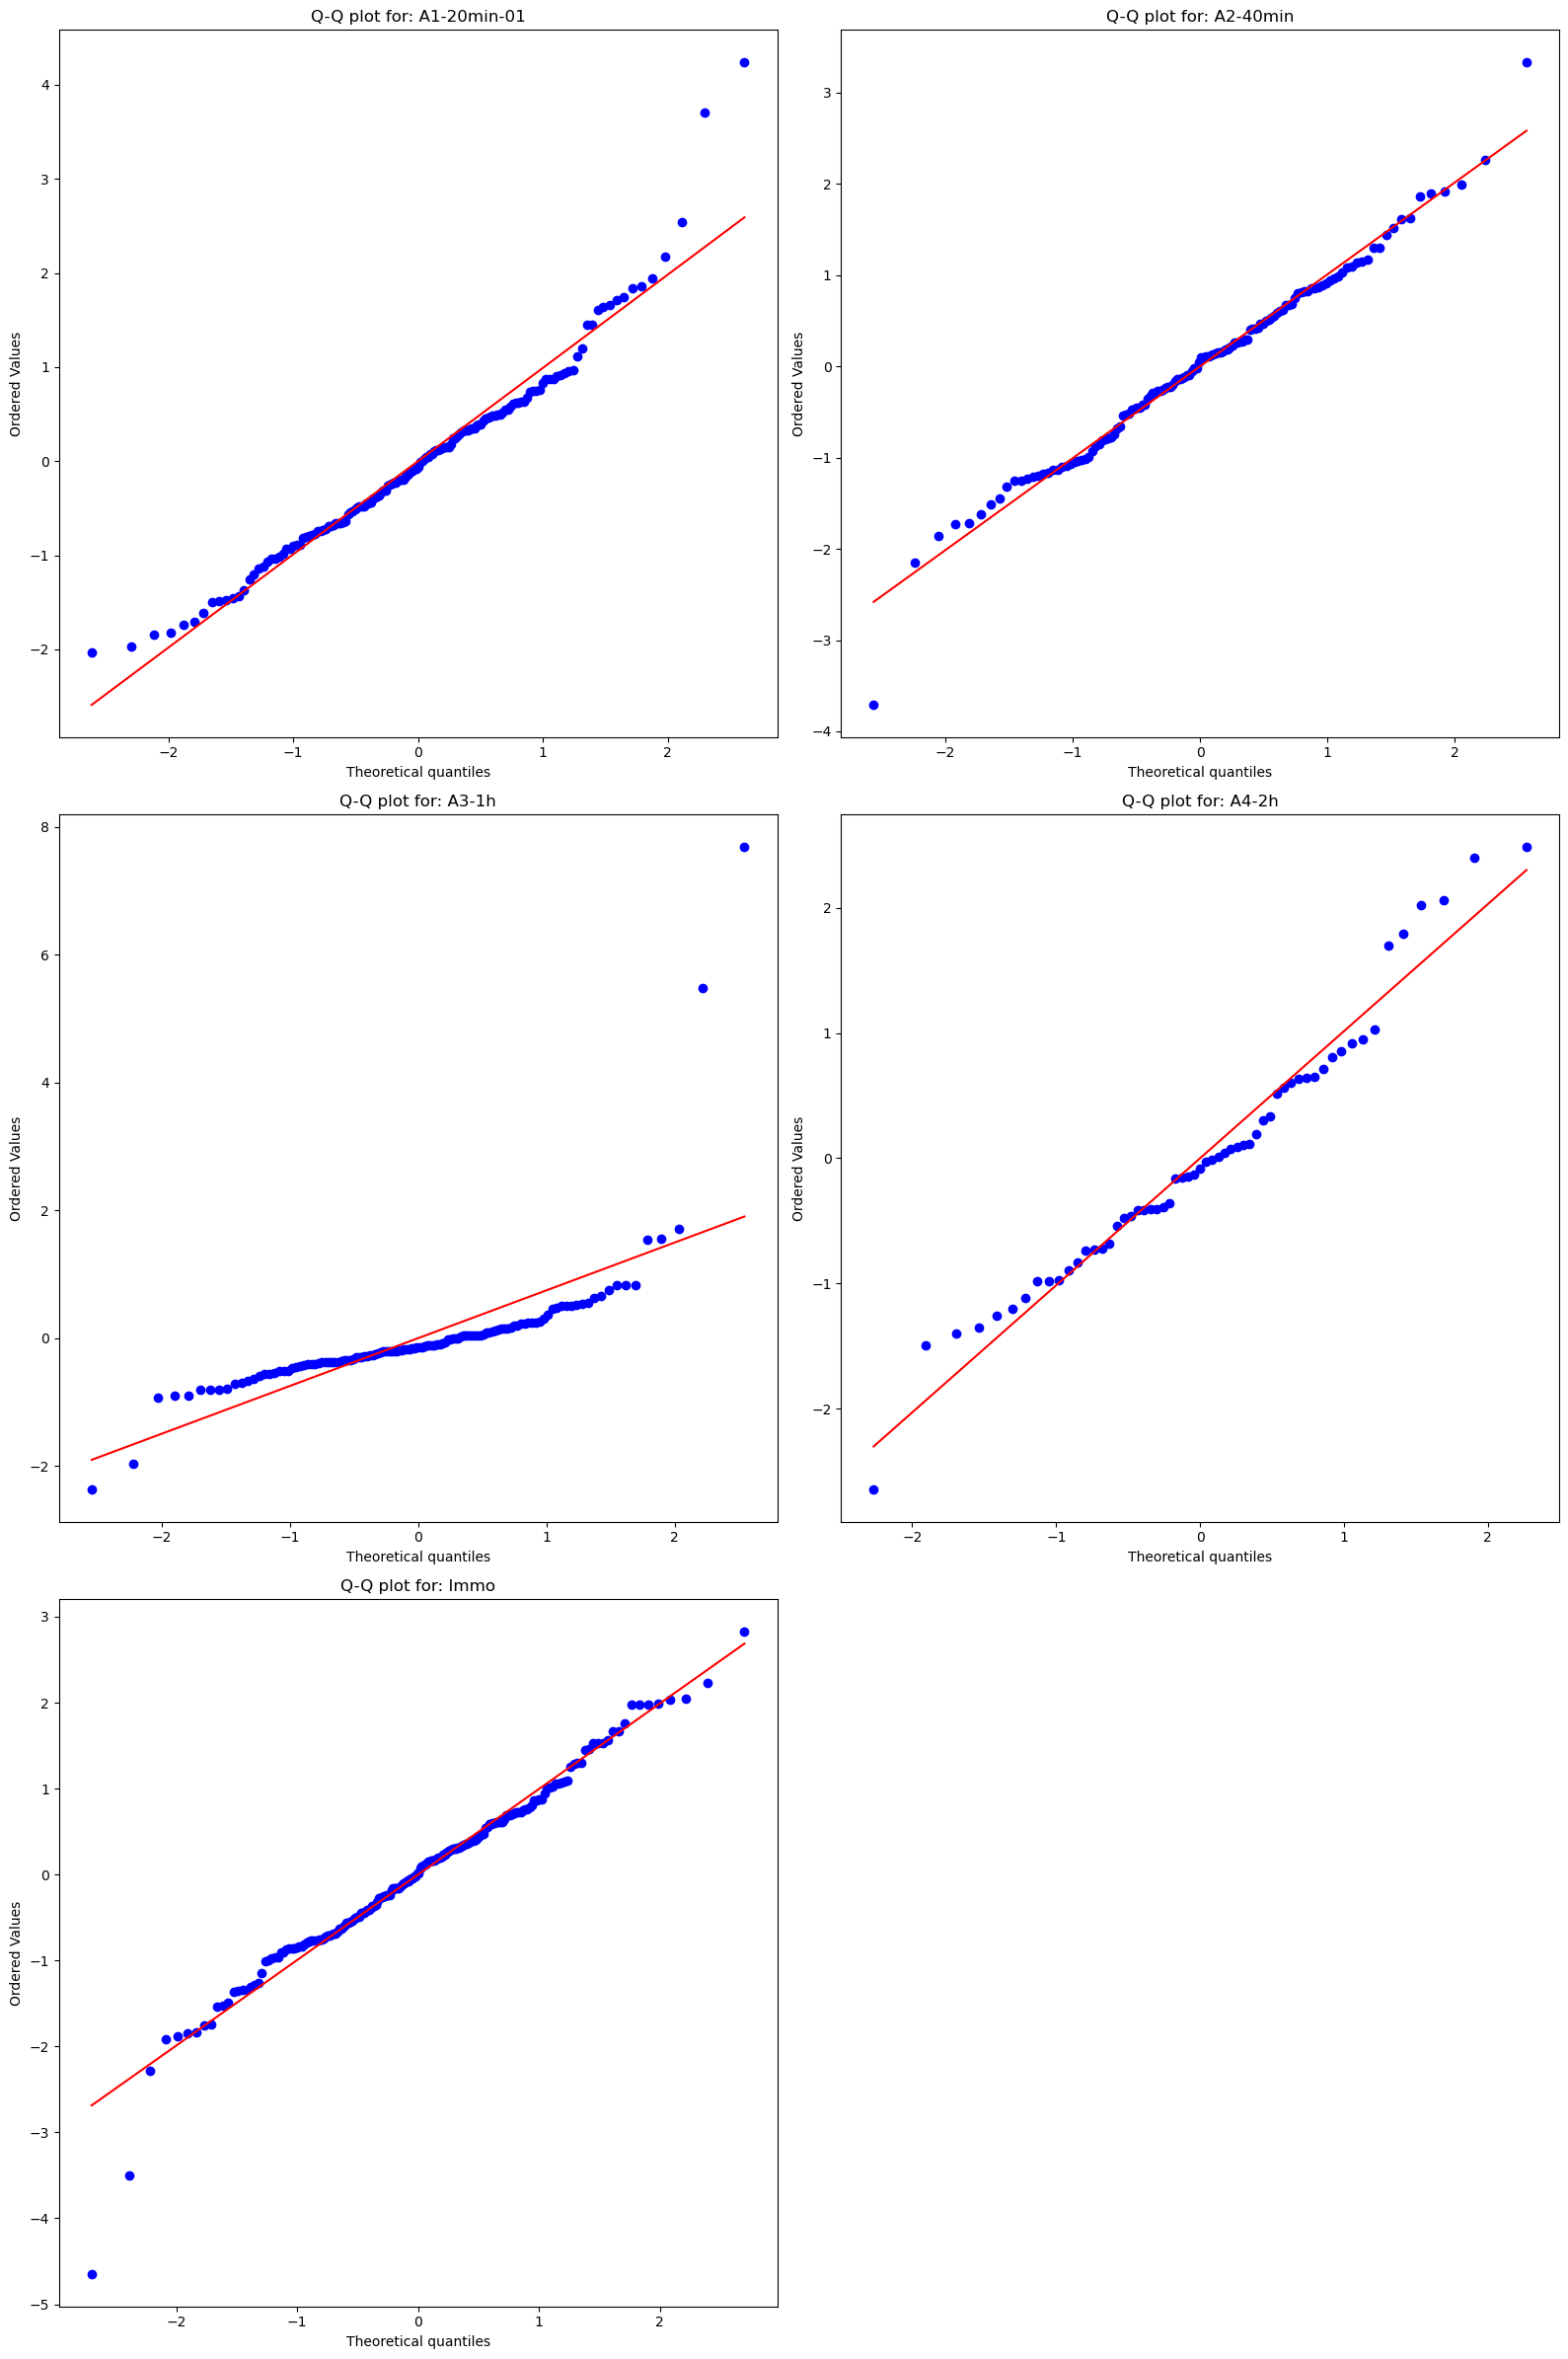

<Figure size 640x480 with 0 Axes>

In [109]:
plot_quantiles(experiment_df, foldername)
